# Kapuã QRNG — série de análises e usos da aleatoriedade

Este notebook **consome a API real de produção** (`https://bongo.dobslit.com/qrng/v1`)
com um **token pessoal** e roda uma bateria de análises estatísticas e de uso sobre os
bytes recebidos.

**Como usar o token (sem escrevê-lo aqui):**

```bash
export KAPUA_API_TOKEN="dobslit_qrng_live_..."   # o SEU token; nunca versione
jupyter lab kapua_qrng_analises.ipynb
```

O notebook lê `os.environ["KAPUA_API_TOKEN"]`. Nenhuma célula contém um token.

**Contrato usado (verificado):** `TRANSPORT UNIT = byte`; `TRANSPORT WORD = uint32
little-endian`; `SOURCE PHYSICAL SAMPLE = desconhecida`; `CONDITIONING = ausente no
software / não confirmado na FPGA`. A produção informa hoje, de propósito,
`provenance = "unknown"`, `live_verified = false`, `captured_at = null`.

> **Leitura dos resultados.** Os testes abaixo são **empíricos, sobre a(s) amostra(s)
> baixada(s) agora**. Passar nestes testes rápidos **não** é: prova de IID, "100%
> aleatório", ausência de viés, validação NIST SP 800-90B, nem aptidão criptográfica.
> A caracterização física e a validação operacional da fonte **continuam em andamento**
> (ver `docs/GUIA_DO_USUARIO_KAPUA.md`).

In [1]:
import os, sys, io, json, time, zlib, hashlib, base64, struct, urllib.request, urllib.parse, urllib.error
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

BASE = "https://bongo.dobslit.com/qrng/v1"
TOKEN = os.environ.get("KAPUA_API_TOKEN", "")
assert TOKEN and TOKEN != "SEU_TOKEN_AQUI", (
    "Defina KAPUA_API_TOKEN no ambiente antes de abrir o notebook. "
    "Nunca escreva o token numa célula."
)
HDR = {"Authorization": f"Bearer {TOKEN}"}
np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.dpi"] = 110
print(f"token detectado ({len(TOKEN)} caracteres) — nunca impresso nem gravado neste notebook.")

token detectado (58 caracteres) — nunca impresso nem gravado neste notebook.


## 1. Autenticação, saúde e cota

Confirma que o token funciona, mostra o estado do *upstream* e quanto da cota diária
resta. Repare em `stream_format = uint32-le`, `sample_width_bytes = 4`,
`conditioned = false` e `actual_origin = unknown`.

In [2]:
def api_get(path, params=None, binary=False, timeout=60):
    url = BASE + path + (("?" + urllib.parse.urlencode(params)) if params else "")
    req = urllib.request.Request(url, headers={**HDR,
        "Accept": "application/octet-stream" if binary else "application/json"})
    try:
        with urllib.request.urlopen(req, timeout=timeout) as r:
            hdrs = {k.lower(): v for k, v in r.headers.items()}
            body = r.read()
            return hdrs, (body if binary else json.loads(body.decode()))
    except urllib.error.HTTPError as e:
        raise RuntimeError(f"HTTP {e.code}: {e.read().decode()[:200]}") from None

_, health = api_get("/health")
up = health["upstream"]
print("api        :", health["api"], "| status:", health["status"])
print("proveniência:", health["provenance"], "| live_verified:", health["provenance_detail"]["live_verified"])
print("upstream    : source_status=%s  buffer=%s/%s B  stream_format=%s  sample_width=%s  conditioned=%s"
      % (up["source_status"], up["buffer_bytes_available"], up["buffer_capacity"],
         up["stream_format"], up["sample_width_bytes"], up["conditioned"]))

_, usage = api_get("/me/usage")
print("\ncota diária : %d/%d requisições  |  %d/%d bytes  (restam %d bytes)"
      % (usage["requests_today"], usage["quota_daily_requests"],
         usage["bytes_today"], usage["quota_daily_bytes"], usage["remaining_bytes_today"]))

api        : dobslit-qrng-client-api | status: ok
proveniência: unknown | live_verified: False
upstream    : source_status=online  buffer=226042632/268435456 B  stream_format=uint32-le  sample_width=4  conditioned=False

cota diária : 12/10000 requisições  |  6291520/104857600 bytes  (restam 98566080 bytes)


## 2. Aquisição da amostra

Baixo **3 blocos de 1 MiB** em `format=raw` (binário puro, N bytes exatos) e concateno
os dois primeiros na amostra principal `S` (2 MiB); o terceiro bloco `Ppi` fica
reservado para o Monte Carlo de π.

Cada requisição é uma **amostra independente** — os SHA-256 dos três blocos são
diferentes (é o esperado de uma fonte de aleatoriedade; nunca "prove" equivalência de
formatos comparando chamadas live).

In [3]:
def fetch_raw(nbytes):
    t0 = time.time()
    h, data = api_get("/random", {"bytes": nbytes, "format": "raw"}, binary=True)
    assert len(data) == nbytes, (len(data), nbytes)
    assert data[:3] != b"\xef\xbb\xbf", "BOM inesperado"
    return np.frombuffer(data, dtype=np.uint8).copy(), h, time.time() - t0

MiB = 1024 * 1024
blocks = []
for i in range(3):
    b, h, dt = fetch_raw(MiB)
    blocks.append(b)
    print(f"bloco {i}: {b.size} B  sha256={hashlib.sha256(b).hexdigest()[:16]}…  "
          f"{dt*1000:5.0f} ms  X-QRNG-Provenance={h.get('x-qrng-provenance')}  "
          f"Conditioned={h.get('x-qrng-conditioned')}")

S = np.concatenate(blocks[:2])          # amostra principal: 2 MiB
Ppi = blocks[2]                         # reservado p/ Monte Carlo de π
print(f"\namostra principal S: {S.size} bytes ({S.size/MiB:.0f} MiB)  "
      f"sha256={hashlib.sha256(S).hexdigest()}")
bits = np.unpackbits(S)                 # 1 bit por elemento, MSB-first
print(f"bits: {bits.size}  (proporção de 1s = {bits.mean():.6f})")

bloco 0: 1048576 B  sha256=77d24c8a964aa9c2…   4978 ms  X-QRNG-Provenance=unknown  Conditioned=false
bloco 1: 1048576 B  sha256=2d47a8224d5a4a00…   4780 ms  X-QRNG-Provenance=unknown  Conditioned=false
bloco 2: 1048576 B  sha256=85fcd4cc9a8526b1…   4749 ms  X-QRNG-Provenance=unknown  Conditioned=false

amostra principal S: 2097152 bytes (2 MiB)  sha256=8a5a880be50d04a2a55a463a03a57d3541e78021d08e0a0d30484522b4d21240
bits: 16777216  (proporção de 1s = 0.501354)


## 3. Distribuição dos valores de byte (0–255) — teste qui-quadrado

Se a fonte for uniforme sobre os 256 valores, a contagem de cada valor deve ficar
próxima de `N/256`. O teste **χ²** de aderência (com 255 graus de liberdade) resume o
desvio num p-valor.

N = 2097152   esperado por valor ≈ 8192.0
min contagem = 7918  max = 8496  desvio-padrão = 104.7
χ² = 342.5  (df=255)   p-valor = 0.0002
→ desvio significativo NESTA amostra (repita; verifique buffer_health).


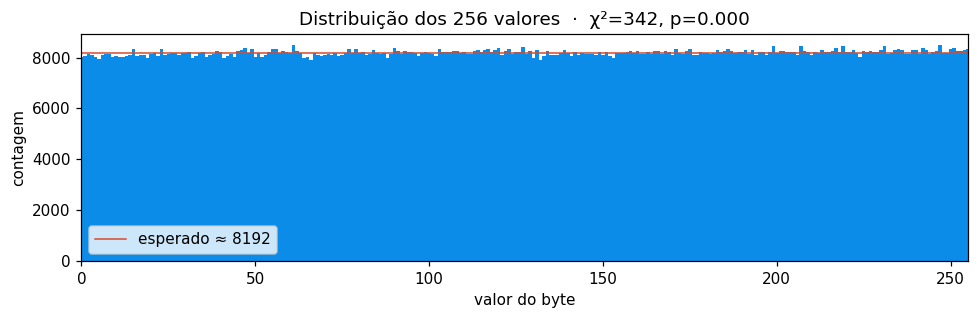

In [4]:
counts = np.bincount(S, minlength=256)
N = S.size
expected = N / 256
chi2 = float(((counts - expected) ** 2 / expected).sum())
p_chi2 = float(stats.chi2.sf(chi2, df=255))
print(f"N = {N}   esperado por valor ≈ {expected:.1f}")
print(f"min contagem = {counts.min()}  max = {counts.max()}  desvio-padrão = {counts.std():.1f}")
print(f"χ² = {chi2:.1f}  (df=255)   p-valor = {p_chi2:.4f}")
print("→ compatível com uniforme nesta amostra." if p_chi2 > 0.01
      else "→ desvio significativo NESTA amostra (repita; verifique buffer_health).")

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(np.arange(256), counts, width=1.0, color="#0c8ce9")
ax.axhline(expected, color="#d94a2e", lw=1, label=f"esperado ≈ {expected:.0f}")
ax.set_xlim(0, 255); ax.set_xlabel("valor do byte"); ax.set_ylabel("contagem")
ax.set_title(f"Distribuição dos 256 valores  ·  χ²={chi2:.0f}, p={p_chi2:.3f}")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Entropia da amostra (Shannon) e min-entropia empírica

- **Entropia de Shannon** por byte: `H = −Σ p·log₂p` (máx. 8 bits).
- **Min-entropia empírica**: `H∞ = −log₂(max p)` — mede o valor mais provável; é a
  quantidade conservadora que a família SP 800-90B usa.

> Estes são estimadores **desta amostra**. Não substituem a suíte SP 800-90B (página
> "Teste NIST" do portal), que usa 10 estimadores e trilhas IID / não-IID.

In [5]:
p = counts / N
p_nz = p[p > 0]
H_shannon = float(-(p_nz * np.log2(p_nz)).sum())
H_min = float(-np.log2(p.max()))
# entropia por bit (monobit): H2 do bit
pb = bits.mean()
H_bit = float(-(pb*np.log2(pb) + (1-pb)*np.log2(1-pb))) if 0 < pb < 1 else 0.0
print(f"Shannon por byte      : {H_shannon:.5f} / 8  bits")
print(f"min-entropia empírica : {H_min:.5f} / 8  bits   (valor mais provável: byte {p.argmax()}, p={p.max():.5f})")
print(f"entropia do bit       : {H_bit:.6f} / 1  bit    (p(1) = {pb:.6f})")
print(f"redundância aparente  : {8 - H_shannon:.5f} bits/byte")

Shannon por byte      : 7.99988 / 8  bits
min-entropia empírica : 7.94743 / 8  bits   (valor mais provável: byte 61, p=0.00405)
entropia do bit       : 0.999995 / 1  bit    (p(1) = 0.501354)
redundância aparente  : 0.00012 bits/byte


## 5. Frequência de bits (monobit) e teste de corridas (runs)

Dois testes clássicos do NIST SP 800-22 sobre a sequência de bits:

- **Monobit**: `#1s` deve ≈ `#0s`. Estatística `S = (n1 − n0)/√n`, p = `erfc(|S|/√2)`.
- **Runs**: número de "corridas" (blocos maximais de bits iguais). Sob aleatoriedade,
  `runs ≈ 1 + 2·n·π·(1−π)`.

In [6]:
n = bits.size
n1 = int(bits.sum()); n0 = n - n1
S_mono = (n1 - n0) / np.sqrt(n)
p_mono = float(stats.chi2.sf(S_mono**2, df=1))       # = erfc(|S|/√2)
print(f"monobit: n1={n1}  n0={n0}  S={S_mono:+.3f}  p={p_mono:.4f}  "
      + ("OK" if p_mono > 0.01 else "DESVIO"))

pi_hat = bits.mean()
runs = 1 + int(np.count_nonzero(bits[1:] != bits[:-1]))
exp_runs = 1 + 2 * n * pi_hat * (1 - pi_hat)
var_runs = 2 * n * pi_hat * (1 - pi_hat) * (2 * pi_hat * (1 - pi_hat) - 1 / n)
z_runs = (runs - exp_runs) / np.sqrt(var_runs)
p_runs = float(stats.chi2.sf(z_runs**2, df=1))
print(f"runs   : obs={runs}  esperado={exp_runs:.0f}  z={z_runs:+.3f}  p={p_runs:.4f}  "
      + ("OK" if p_runs > 0.01 else "DESVIO"))

monobit: n1=8411327  n0=8365889  S=+11.093  p=0.0000  DESVIO
runs   : obs=8385819  esperado=8388547  z=-1.332  p=0.1828  OK


## 6. Teste espectral (DFT) da sequência de bits

Converte os bits para `±1` e olha o **espectro de potência**. Sob aleatoriedade, não deve
haver frequências dominantes: a fração de magnitudes abaixo do limiar
`T = √(2.995732·n)` deve ficar perto de 95 %.

m=1048576 bits  limiar T=1772.4
magnitudes < T : 498137/524287 = 0.9501  (esperado ≈ 0.95)  p≈0.4148


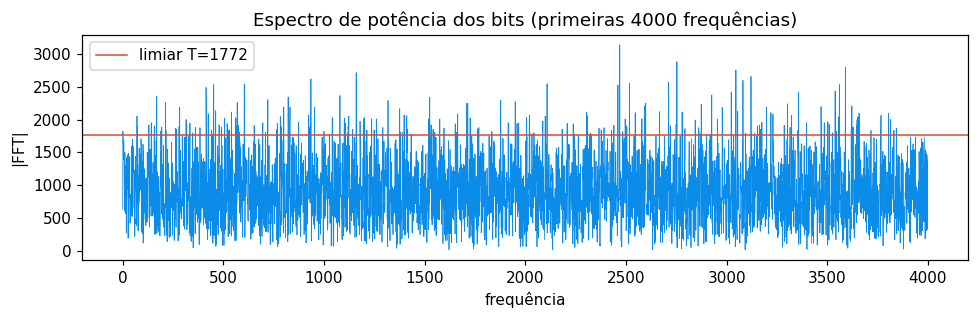

In [7]:
m = 1 << 20                              # 1.048.576 bits para a DFT (potência de 2)
x = 2.0 * bits[:m].astype(np.float64) - 1.0
F = np.abs(np.fft.rfft(x))[1:m // 2]     # descarta DC
T = np.sqrt(np.log(1 / 0.05) * m)        # limiar NIST SP 800-22
below = int((F < T).sum()); total = F.size
frac = below / total
exp_frac = 0.95
d = (below - exp_frac * total) / np.sqrt(total * exp_frac * (1 - exp_frac) / 4)  # aprox. NIST
p_dft = float(stats.chi2.sf(d**2, df=1))
print(f"m={m} bits  limiar T={T:.1f}")
print(f"magnitudes < T : {below}/{total} = {frac:.4f}  (esperado ≈ 0.95)  p≈{p_dft:.4f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(F[:4000], lw=0.5, color="#0c8ce9")
ax.axhline(T, color="#d94a2e", lw=1, label=f"limiar T={T:.0f}")
ax.set_title("Espectro de potência dos bits (primeiras 4000 frequências)")
ax.set_xlabel("frequência"); ax.set_ylabel("|FFT|"); ax.legend()
plt.tight_layout(); plt.show()

## 7. "Parece ruído?" — bitmap dos bytes

Renderiza os primeiros `512×512` bits como preto/branco. Um gerador estruturado deixa
faixas, xadrez ou gradientes visíveis; ruído bom fica sem padrão.

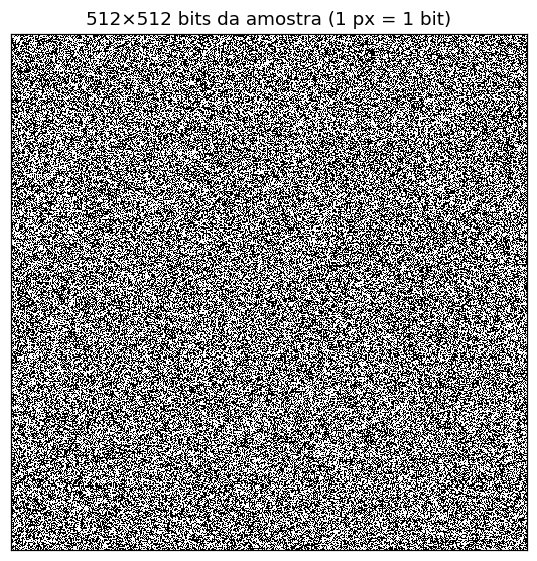

In [8]:
side = 512
img = bits[:side * side].reshape(side, side)
fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.imshow(img, cmap="binary", interpolation="nearest")
ax.set_title(f"{side}×{side} bits da amostra (1 px = 1 bit)")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 8. Dependência serial — autocorrelação e dispersão lag-1

- **Autocorrelação** dos valores de byte para defasagens 1..64. Sob independência, cada
  coeficiente cai dentro de `±1.96/√N` em ~95 % dos casos.
- **Dispersão lag-1**: `byte[i]` vs `byte[i+1]`. Deve ser uma nuvem uniforme. Ao lado,
  um **LCG** clássico (PRNG determinístico, *para comparação*) que revela retas/planos.

autocorrelação lag 1..64: 3/64 fora da banda ±0.00135  (≈3 esperados sob independência)
corr(byte[i], byte[i+1]) = +0.00005


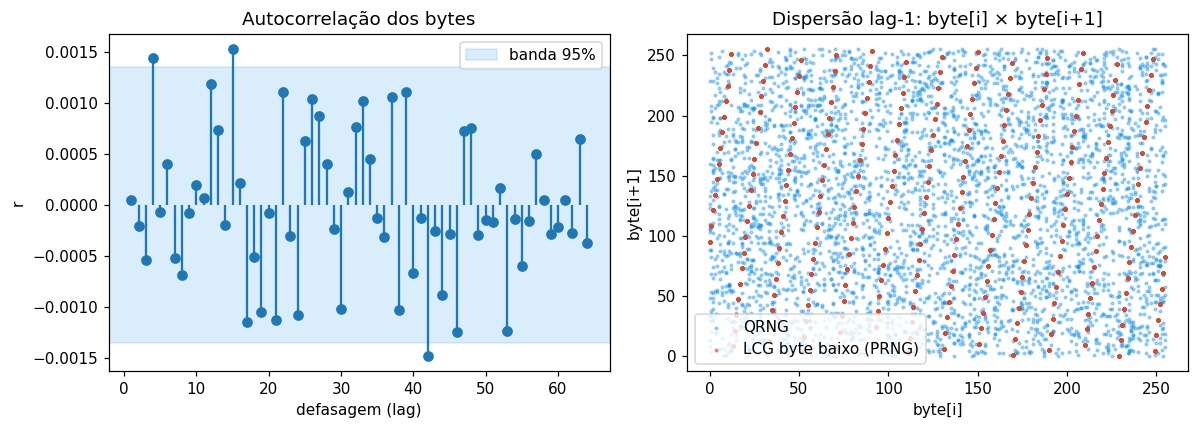

In [9]:
xb = S.astype(np.float64) - S.mean()
den = np.dot(xb, xb)
lags = np.arange(1, 65)
acf = np.array([np.dot(xb[:-k], xb[k:]) / den for k in lags])
band = 1.96 / np.sqrt(S.size)
out = int(np.count_nonzero(np.abs(acf) > band))
print(f"autocorrelação lag 1..64: {out}/64 fora da banda ±{band:.5f}  "
      f"(≈3 esperados sob independência)")
print(f"corr(byte[i], byte[i+1]) = {acf[0]:+.5f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].stem(lags, acf, basefmt=" ")
ax[0].axhspan(-band, band, color="#0c8ce9", alpha=0.15, label="banda 95%")
ax[0].set_title("Autocorrelação dos bytes"); ax[0].set_xlabel("defasagem (lag)")
ax[0].set_ylabel("r"); ax[0].legend()

k = 4000
ax[1].scatter(S[:k], S[1:k+1], s=3, alpha=0.35, color="#0c8ce9", label="QRNG")
# LCG determinístico, BYTE BAIXO (período curto dos bits baixos) — SÓ para
# contraste: o byte baixo de um LCG tem estrutura lag-1 rígida (linhas diagonais).
seed = 12345; a, c, m2 = 1664525, 1013904223, 2**32
lcg = np.empty(k+1, dtype=np.int64)
for i in range(k+1):
    seed = (a*seed + c) % m2; lcg[i] = seed & 0xFF
ax[1].scatter(lcg[:k], lcg[1:k+1], s=3, alpha=0.5, color="#d94a2e", label="LCG byte baixo (PRNG)")
ax[1].set_title("Dispersão lag-1: byte[i] × byte[i+1]")
ax[1].set_xlabel("byte[i]"); ax[1].set_ylabel("byte[i+1]"); ax[1].legend()
plt.tight_layout(); plt.show()

## 9. Incompressibilidade

Dados verdadeiramente aleatórios não comprimem. Comparo a razão de compressão
(`zlib` nível 9) da amostra QRNG com a de uma sequência do LCG e a de texto repetido.

In [10]:
def ratio(b): return len(zlib.compress(bytes(b), 9)) / len(b)
lcg_bytes = np.frombuffer(np.random.default_rng(0).integers(0, 256, S.size, dtype=np.uint8).tobytes(), np.uint8)
# ^ np.random é PRNG — usado só como referência de "quase incompressível"
txt = (b"a aleatoriedade e importante. " * (S.size // 29 + 1))[:S.size]
print(f"QRNG (amostra) : razão de compressão = {ratio(S):.5f}")
print(f"PRNG (numpy)   : razão de compressão = {ratio(lcg_bytes):.5f}")
print(f"texto repetido : razão de compressão = {ratio(txt):.5f}")
print("→ razão ≈ 1.00 indica ausência de redundância explorável por zlib.")

QRNG (amostra) : razão de compressão = 1.00031
PRNG (numpy)   : razão de compressão = 1.00031
texto repetido : razão de compressão = 0.00245
→ razão ≈ 1.00 indica ausência de redundância explorável por zlib.


## 10. Uso: `uint32` little-endian → uniforme em [0, 1)

`x = b₀ + b₁·2⁸ + b₂·2¹⁶ + b₃·2²⁴` (little-endian, como o transporte declara);
`u = x / 2³² ∈ [0, 1)` (nunca ≥ 1). Histograma + **teste de Kolmogorov–Smirnov** contra
a uniforme.

524288 valores  min=0.000001148  max=0.999999558  média=0.501932 (esperado 0.5)
KS vs Uniforme(0,1): D=0.00343  p=0.0000


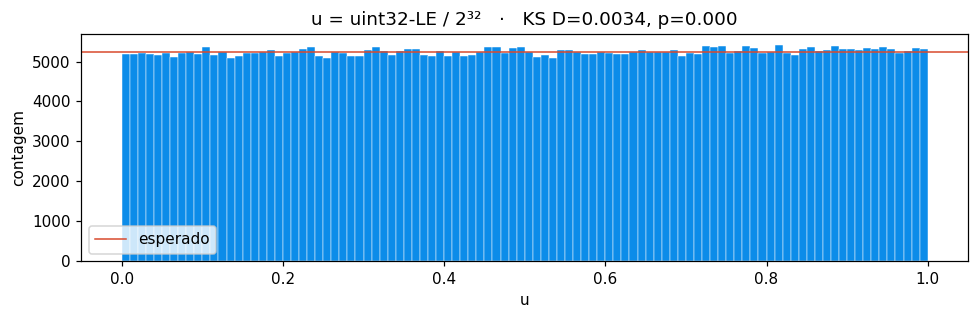

In [11]:
w = S.size - (S.size % 4)
u32 = np.frombuffer(S[:w].tobytes(), dtype="<u4")     # '<u4' = uint32 little-endian
U = u32.astype(np.float64) / 2**32
assert U.max() < 1.0 and U.min() >= 0.0
ks = stats.kstest(U, "uniform")
print(f"{U.size} valores  min={U.min():.9f}  max={U.max():.9f}  média={U.mean():.6f} (esperado 0.5)")
print(f"KS vs Uniforme(0,1): D={ks.statistic:.5f}  p={ks.pvalue:.4f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(U, bins=100, color="#0c8ce9", edgecolor="white", linewidth=0.3)
ax.axhline(U.size/100, color="#d94a2e", lw=1, label="esperado")
ax.set_title(f"u = uint32-LE / 2³²   ·   KS D={ks.statistic:.4f}, p={ks.pvalue:.3f}")
ax.set_xlabel("u"); ax.set_ylabel("contagem"); ax.legend()
plt.tight_layout(); plt.show()

## 11. Uso: estimativa de π por Monte Carlo

Cada ponto usa **8 bytes** (dois `uint32`): `x = u₁`, `y = u₂`; conta os que caem em
`x² + y² ≤ 1`. `π̂ = 4·dentro/total`. A curva de erro deve cair como `n^(−1/2)`.

131072 pontos  ·  π̂ = 3.141296  ·  π = 3.141593  ·  erro = 0.0094%


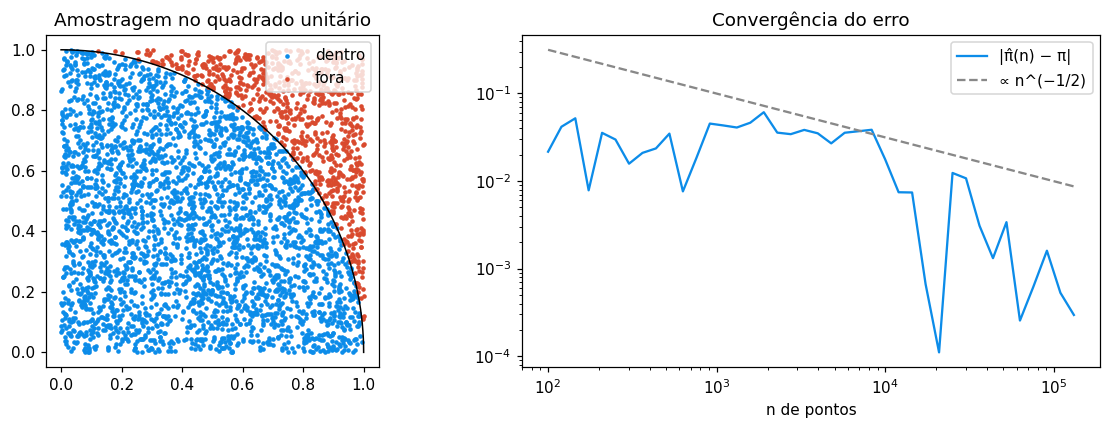

In [12]:
wp = Ppi.size - (Ppi.size % 8)
pts = np.frombuffer(Ppi[:wp].tobytes(), dtype="<u4").astype(np.float64) / 2**32
xs, ys = pts[0::2], pts[1::2]
n_pts = xs.size
inside = (xs*xs + ys*ys) <= 1.0
pi_hat = 4.0 * inside.mean()
err = abs(pi_hat - np.pi) / np.pi * 100
print(f"{n_pts} pontos  ·  π̂ = {pi_hat:.6f}  ·  π = {np.pi:.6f}  ·  erro = {err:.4f}%")

k = np.unique(np.round(np.logspace(2, np.log10(n_pts), 40)).astype(int))
run_pi = 4.0 * np.cumsum(inside)[k-1] / k
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
s = slice(0, 4000)
ax[0].scatter(xs[s][inside[s]], ys[s][inside[s]], s=4, color="#0c8ce9", label="dentro")
ax[0].scatter(xs[s][~inside[s]], ys[s][~inside[s]], s=4, color="#d94a2e", label="fora")
t = np.linspace(0, np.pi/2, 200); ax[0].plot(np.cos(t), np.sin(t), color="k", lw=1)
ax[0].set_aspect("equal"); ax[0].set_title("Amostragem no quadrado unitário"); ax[0].legend()
ax[1].loglog(k, np.abs(run_pi - np.pi), color="#0c8ce9", label="|π̂(n) − π|")
ax[1].loglog(k, np.pi*k**-0.5, "--", color="#888", label="∝ n^(−1/2)")
ax[1].set_title("Convergência do erro"); ax[1].set_xlabel("n de pontos"); ax[1].legend()
plt.tight_layout(); plt.show()

## 12. Uso: dado justo 1–6 sem viés de módulo (rejection sampling)

`d mod 6` introduz viés porque 256 (e 2³²) não é múltiplo de 6. O **rejection sampling**
descarta o topo do intervalo que não é múltiplo de `range` e elimina o viés.

524288 lançamentos  (descartados por rejeição: 0)
  face 1:   87261   (16.644%)
  face 2:   87269   (16.645%)
  face 3:   87499   (16.689%)
  face 4:   87419   (16.674%)
  face 5:   87319   (16.655%)
  face 6:   87521   (16.693%)
χ² = 0.75 (df=5)   p = 0.9800   dado compatível com justo.


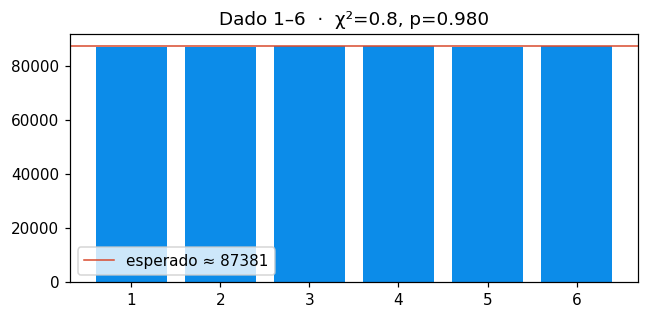

In [13]:
def dice_from_u32(words, faces=6):
    limit = (2**32 // faces) * faces
    keep = words[words < limit]
    return (keep % faces).astype(np.int64) + 1

rolls = dice_from_u32(u32, 6)
freq = np.bincount(rolls, minlength=7)[1:]
exp = rolls.size / 6
chi2_d = float(((freq - exp)**2 / exp).sum())
p_d = float(stats.chi2.sf(chi2_d, df=5))
print(f"{rolls.size} lançamentos  (descartados por rejeição: {u32.size - rolls.size})")
for f in range(6):
    print(f"  face {f+1}: {freq[f]:7d}   ({freq[f]/rolls.size*100:.3f}%)")
print(f"χ² = {chi2_d:.2f} (df=5)   p = {p_d:.4f}   "
      + ("dado compatível com justo." if p_d > 0.01 else "DESVIO nesta amostra."))

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(np.arange(1, 7), freq, color="#0c8ce9")
ax.axhline(exp, color="#d94a2e", lw=1, label=f"esperado ≈ {exp:.0f}")
ax.set_xticks(range(1, 7)); ax.set_title(f"Dado 1–6  ·  χ²={chi2_d:.1f}, p={p_d:.3f}")
ax.legend(); plt.tight_layout(); plt.show()

## 13. Uso: passeio aleatório 2D

Cada passo consome **2 bits** (`00`=↑, `01`=↓, `10`=←, `11`=→). Traço uma trajetória
longa e comparo o deslocamento final de muitas trajetórias curtas com a lei `√passos`.

16384 trajetórias de 512 passos  ·  deslocamento final médio = 20.03  (previsão √(πL/4) ≈ 20.05)


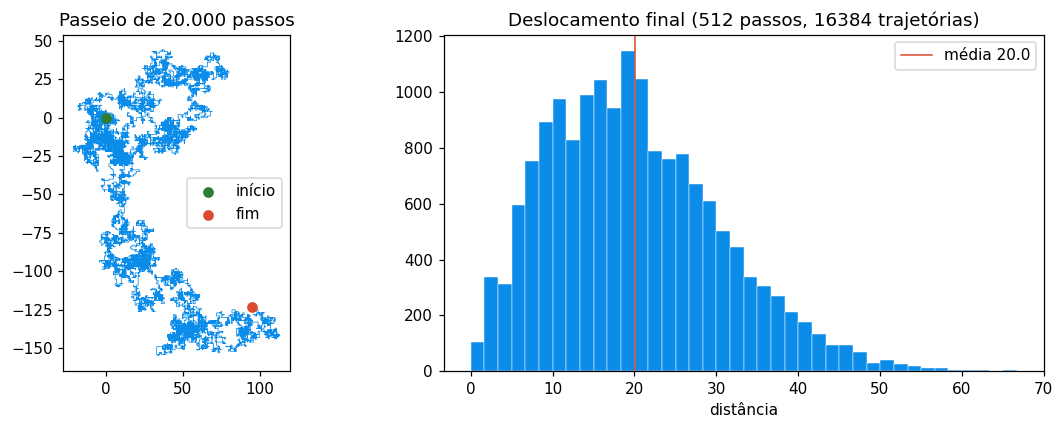

In [14]:
b2 = bits[: (bits.size // 2) * 2].reshape(-1, 2)
step_id = b2[:, 0] * 2 + b2[:, 1]
DVEC = np.array([[0, 1], [0, -1], [-1, 0], [1, 0]])
steps = DVEC[step_id]

path = np.cumsum(steps[:20000], axis=0)
L = 512; K = steps.shape[0] // L
disp = np.linalg.norm(np.cumsum(steps[:K*L].reshape(K, L, 2), axis=1)[:, -1, :], axis=1)
print(f"{K} trajetórias de {L} passos  ·  deslocamento final médio = {disp.mean():.2f}  "
      f"(previsão √(πL/4) ≈ {np.sqrt(np.pi*L/4):.2f})")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(path[:, 0], path[:, 1], lw=0.5, color="#0c8ce9")
ax[0].scatter([0], [0], color="#2e7d32", zorder=3, label="início")
ax[0].scatter([path[-1, 0]], [path[-1, 1]], color="#d94a2e", zorder=3, label="fim")
ax[0].set_aspect("equal"); ax[0].set_title("Passeio de 20.000 passos"); ax[0].legend()
ax[1].hist(disp, bins=40, color="#0c8ce9", edgecolor="white", linewidth=0.3)
ax[1].axvline(disp.mean(), color="#d94a2e", lw=1, label=f"média {disp.mean():.1f}")
ax[1].set_title(f"Deslocamento final ({L} passos, {K} trajetórias)")
ax[1].set_xlabel("distância"); ax[1].legend()
plt.tight_layout(); plt.show()

## 14. Uso: colisões de aniversário (checagem contra a teoria)

Divido a amostra em janelas de `k` valores de 16 bits e conto quantas janelas têm ao
menos uma repetição. A probabilidade teórica é
`1 − Π_{i=0}^{k−1}(1 − i/2¹⁶)`.

In [15]:
v16 = np.frombuffer(S[:(S.size//2)*2].tobytes(), dtype="<u2")
for k in (23, 100, 300):
    W = v16.size // k
    win = v16[:W*k].reshape(W, k)
    has_dup = np.array([len(np.unique(r)) < k for r in win])
    emp = has_dup.mean()
    idx = np.arange(k)
    theo = 1.0 - np.prod(1.0 - idx / 65536.0)
    print(f"k={k:4d}  janelas={W:5d}  P(colisão) empírica={emp:.4f}  teórica={theo:.4f}")

k=  23  janelas=45590  P(colisão) empírica=0.0043  teórica=0.0039
k= 100  janelas=10485  P(colisão) empírica=0.0734  teórica=0.0728
k= 300  janelas= 3495  P(colisão) empírica=0.4970  teórica=0.4961


## 15. Uso: bytes para semente / material de chave (com ressalva)

Como obter, por exemplo, 32 bytes para semear um RNG ou como *entrada* de um KDF.

> **Ressalva importante.** A API do Kapuã **não** habilita geração criptográfica
> operacional (os endpoints `/v1/entropy`, `/v1/random/cryptographic`, `/v1/keys`,
> `/v1/seed`, `/v1/nonce` retornam 404) enquanto a fonte está em validação. Para
> **pesquisa e simulação** os bytes servem; para **chaves/nonces de produção**, aguarde
> a arquitetura criptográfica aderente à SP 800-90A/B/C.

In [16]:
seed_bytes, _, _ = fetch_raw(32)
seed_hex = seed_bytes.tobytes().hex()
seed_u64 = int.from_bytes(seed_bytes[:8].tobytes(), "little")
print("32 bytes (hex):", seed_hex[:32] + "…")
print("uint64 (LE) p/ np.random.default_rng():", seed_u64)
print("SHA-256 desses 32 bytes (ex.: entrada de KDF):", hashlib.sha256(seed_bytes).hexdigest())
rng = np.random.default_rng(seed_u64)
print("amostra reprodutível a partir dessa semente:", rng.integers(0, 100, 8))

32 bytes (hex): ca8043e91adfe3473d3929c5c83171cc…
uint64 (LE) p/ np.random.default_rng(): 5180229303081861322
SHA-256 desses 32 bytes (ex.: entrada de KDF): 10d9326dfaf5bbebee93c24194d290282c1fe9def11df72c3b3c3829601a0b1a
amostra reprodutível a partir dessa semente: [34 97 54 23 48 26 72 36]


## 16. Síntese

Resumo dos testes rodados sobre a(s) amostra(s) baixada(s) agora.

In [17]:
rows = [
    ("Byte uniforme (χ², df=255)",      f"χ²={chi2:.0f}",            p_chi2),
    ("Monobit",                          f"S={S_mono:+.2f}",          p_mono),
    ("Runs",                             f"z={z_runs:+.2f}",          p_runs),
    ("Espectral (DFT)",                  f"{frac:.3f} < T",           p_dft),
    ("Uniforme u=x/2³² (KS)",            f"D={ks.statistic:.4f}",     ks.pvalue),
    ("Dado 1–6 (χ², df=5)",              f"χ²={chi2_d:.1f}",          p_d),
]
print(f"{'teste':32s} {'estatística':>14s} {'p-valor':>10s}   veredito (nesta amostra)")
print("-" * 82)
for name, stat, pv in rows:
    verd = "compatível com aleatório" if pv > 0.01 else "desvio — repetir/investigar"
    print(f"{name:32s} {stat:>14s} {pv:10.4f}   {verd}")
print("-" * 82)
print(f"Shannon/byte = {H_shannon:.4f}/8   min-entropia empírica = {H_min:.4f}/8   "
      f"compressão zlib = {ratio(S):.4f}")
print()
print("LEMBRE-SE: passar nestes testes rápidos NÃO é validação SP 800-90B, NÃO prova IID,")
print("NÃO garante aptidão criptográfica. A produção reporta provenance='unknown' e a")
print("caracterização física da fonte segue em andamento (ver docs/GUIA_DO_USUARIO_KAPUA.md).")

teste                               estatística    p-valor   veredito (nesta amostra)
----------------------------------------------------------------------------------
Byte uniforme (χ², df=255)               χ²=342     0.0002   desvio — repetir/investigar
Monobit                                S=+11.09     0.0000   desvio — repetir/investigar
Runs                                    z=-1.33     0.1828   compatível com aleatório
Espectral (DFT)                       0.950 < T     0.4148   compatível com aleatório
Uniforme u=x/2³² (KS)                  D=0.0034     0.0000   desvio — repetir/investigar
Dado 1–6 (χ², df=5)                      χ²=0.8     0.9800   compatível com aleatório
----------------------------------------------------------------------------------
Shannon/byte = 7.9999/8   min-entropia empírica = 7.9474/8   compressão zlib = 1.0003

LEMBRE-SE: passar nestes testes rápidos NÃO é validação SP 800-90B, NÃO prova IID,
NÃO garante aptidão criptográfica. A produção reporta

## 17. Interpretação

O que os números acima costumam mostrar nesta fonte, hoje:

- **Viés de 1º momento pequeno, porém mensurável.** O **monobit** e o **χ² dos bytes**
  frequentemente acusam desvio (proporção de 1s tipicamente ≈ `0,499`, um déficit de
  poucos `σ` em milhões de bits). Isso é **coerente com o que o projeto já registrou**:
  min-entropia estimada **abaixo de 8 bits/byte** na trilha não-IID e um viés real e
  reprodutível — a razão de a fonte estar **em validação** e de a geração criptográfica
  operacional estar **desabilitada**.
- **Sem estrutura explorável de curto alcance.** *Runs*, *espectral (DFT)*,
  *autocorrelação lag 1..64*, *KS* sobre `u = x/2³²` e *compressão* `zlib` não acusam
  padrão — a sequência "parece ruído" e serve bem para Monte Carlo, passeios aleatórios,
  amostragem e simulação (π e o passeio 2D acima batem com a teoria com folga).
- **Um p-valor isolado não decide nada.** Rode de novo: alguns testes vão oscilar entre
  "OK" e "desvio". O achado **estável** é o viés de 1º momento; os testes de estrutura
  passam de forma consistente.

Para uma avaliação séria da entropia use a **página "Teste NIST"** do portal (suíte
SP 800-90B completa, trilhas IID / não-IID) — e mesmo ela avalia *a amostra*, não emite
um selo permanente da fonte.